## HST Aperture Photometry Notebook for F657N SN1983V 

In [1]:
%matplotlib inline

In [2]:
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy import wcs


from astropy.visualization import simple_norm
from photutils.aperture import CircularAnnulus
from photutils.datasets import make_100gaussians_image
from photutils.aperture import CircularAperture
from photutils.aperture import SkyCircularAperture
from photutils.aperture import aperture_photometry
from photutils.aperture import ApertureStats
from photutils.datasets import make_wcs


/Users/sophiakressy/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Hubble 657N data

In [3]:
filepath = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/HST/drz_lvl3/F657N_drz.fits'

with fits.open(filepath) as hdu:
        # data = fits.getdata(ifile)
        # hdu = fits.open(ifile)  
        data = hdu[1].data
        fltr = hdu[0].header['FILTER']
        w    = wcs.WCS(hdu[1].header)
        hdr  = hdu[1].header

#### Show filter data

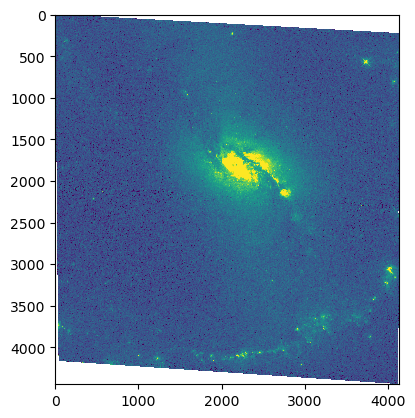

In [4]:
norm = simple_norm(data, 'sqrt', percent=99)
plt.imshow(data, norm=norm, interpolation='nearest')

### center on SN, determine Aperture

In [5]:
# SN location
sn_location = SkyCoord('3:33:31.6159','-36:08:55.222',unit=(u.hourangle,u.deg))
print('SN Location in Deg:', sn_location)

# convert to pixels
x_init, y_init = wcs.utils.skycoord_to_pixel(sn_location,w)
print('SN Location in Pixels:', x_init, y_init)

# determine aperture from SN location
aperture = SkyCircularAperture(sn_location, r=0.15 * u.arcsec)

# convert aperture to pixels
pix_aperture = aperture.to_pixel(w)

print('')
print(aperture)
print(pix_aperture)
print(pix_aperture.positions)
# position = SkyCoord(197.893, -1.366, unit='deg', frame='icrs')

SN Location in Deg: <SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>
SN Location in Pixels: 1114.0631975164529 657.5237768768854

Aperture: SkyCircularAperture
positions: <SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>
r: 0.15 arcsec
Aperture: CircularAperture
positions: [1114.06319752,  657.52377688]
r: 3.7859669320390408
[1114.06319752  657.52377688]


### Determine background; plot

In [7]:
# annulus_aperture = CircularAnnulus(pix_aperture.positions, r_in=10, r_out=15)


In [8]:
# norm = simple_norm(data, 'linear', percent=90)
# plt.imshow(data, norm=norm, interpolation='nearest')
# plt.xlim(1050, 1150)
# plt.ylim(600, 700)

# ap_patches = pix_aperture.plot(color='white', lw=2,
#                            label='Photometry aperture')
# ann_patches = annulus_aperture.plot(color='red', lw=2,
#                                     label='Background annulus')
# handles = (ap_patches[0], ann_patches[0])
# plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
#            handles=handles, prop={'weight': 'bold', 'size': 11})

#### Calculate background flux from region off target, unobstructed by noisy neighbor

In [6]:
# Get off target coords by using SN pixel location; - 20 Pixels off SN
x_back = x_init - 20
y_back = y_init - 20

# convert to degrees
off_target_coords = wcs.utils.pixel_to_skycoord(x_back,y_back,w)
print('Off Target Coords in Deg:',off_target_coords)

# create aperture of background
off_aperture = SkyCircularAperture(off_target_coords, r=0.15 * u.arcsec)

# convert to pixel coords
off_pix_aperture = off_aperture.to_pixel(w)

# create annulus of background (not using)
# off_annulus_aperture = CircularAnnulus(off_pix_aperture.positions, r_in=10, r_out=15)

Off Target Coords in Deg: <SkyCoord (ICRS): (ra, dec) in deg
    (53.38139568, -36.14882359)>


#### Plot aperture of SN and background

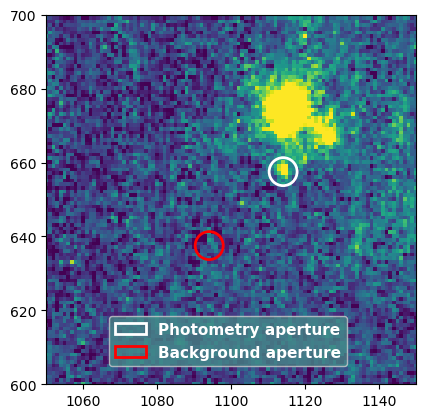

In [7]:
norm = simple_norm(data, 'linear', percent=90)
plt.imshow(data, norm=norm, interpolation='nearest')
plt.xlim(1050, 1150)
plt.ylim(600, 700)

ap_patches = pix_aperture.plot(color='white', lw=2,
                           label='Photometry aperture')
back_patches = off_pix_aperture.plot(color='red', lw=2,
                           label='Background aperture')
# ann_patches = off_annulus_aperture.plot(color='red', lw=2,
#                                     label='Background annulus')
handles = (ap_patches[0], back_patches[0])
plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
           handles=handles, prop={'weight': 'bold', 'size': 11})

#### Find aperture sum of SN target

In [8]:
phot_table = aperture_photometry(data, pix_aperture)
for col in phot_table.colnames:
    phot_table[col].info.format = '%.8g'  # for consistent table output
print(phot_table)

 id  xcenter   ycenter  aperture_sum
--- --------- --------- ------------
  1 1114.0632 657.52378   0.88160044


#### Find aperture sum of background

In [9]:
back_table = aperture_photometry(data, off_pix_aperture)
for col in back_table.colnames:
    back_table[col].info.format = '%.8g'  # for consistent table output
print(back_table)

 id  xcenter   ycenter  aperture_sum
--- --------- --------- ------------
  1 1094.0632 637.52378   0.39534183


#### subtract background aperture sum from SN aperture sum

In [10]:
back_sub_aperature_sum = phot_table['aperture_sum'] - back_table['aperture_sum']

#### Find flux of SN

In [11]:
sn_flux = back_sub_aperature_sum*3.1503195125E-06
no_back_sn_flux = phot_table['aperture_sum']*3.1503195125E-06

print('Background Subtracted: ', sn_flux[0], '[Jy]', np.log10(sn_flux[0]))
print('NOT Background Subtracted: ', no_back_sn_flux[0], '[Jy]', np.log10(no_back_sn_flux[0]))

Background Subtracted:  1.531869970299237e-06 [Jy] -5.814778097352356
NOT Background Subtracted:  2.777323063755246e-06 [Jy] -5.556373599311455


#### Convert Flux to AB Mags

In [12]:
m_AB = -2.5*np.log10(sn_flux[0])+8.90
no_back_m_AB = -2.5*np.log10(no_back_sn_flux[0])+8.90
print('Background Subtracted SN magnitude: ', m_AB)
print('NOT Background Subtracted SN magnitude: ', no_back_m_AB)


Background Subtracted SN magnitude:  23.43694524338089
NOT Background Subtracted SN magnitude:  22.79093399827864


# Convert to solar luminosity

In [13]:
flux = no_back_sn_flux[0] # Jy
# flux = 1.53e-06
print(flux)

2.777323063755246e-06


In [14]:
Jy_to_erg = 1e-23 # erg s-1 cm-2 Hz-1
c = 3.0E18 # A s-1
wave = 6566.58 # Angstroms
# convert to erg s-1 cm-2 A-1
flux_a = flux * Jy_to_erg * c / wave**2 # units = erg s-1 cm-2 A-1

print(flux_a)

1.9322760733834686e-18


In [15]:
# approximate total flux thru F657N filter
# for F657N filter, the effective width = FWHM = 12.1 nm = 121 A

F_line = flux_a * 121 # erg s-1 cm-2
print('Total flux through F657N filter: ', F_line, '[erg s-1 cm-2]')

Total flux through F657N filter:  2.338054048793997e-16 [erg s-1 cm-2]


In [16]:
# Now, find total luminosity in solar luminosity. 
# L = 4 * pi * d^2 * F_line

# redshift = 0.0054 # distance in redshift
mpc_distance = 18 # Mpc
d =  mpc_distance * 3.086e+24 # convert Mpc to cm
L = 4 * np.pi * d**2 * F_line # erg s-1

# Find luminosity in terms of solar luminosity
L_sun = 3.828e33 # erg s-1
L_frac = L / L_sun # in solar luminosity
print(L_frac, '[L_sun]')
print(L, '[erg s-1]')

2368.2597563092604 [L_sun]
9.06569834715185e+36 [erg s-1]


In [17]:
L = 1.0988473473071813e+39 #[erg s^-1]
L_frac = L / L_sun # in solar luminosity
print(L_frac, '[L_sun]')

287055.21089529287 [L_sun]


In [18]:
# data = make_100gaussians_image()
# positions = [(145.1, 168.3), (84.5, 224.1), (48.3, 200.3)]
# aperture = CircularAperture(positions, r=5)
# annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

# norm = simple_norm(data, 'sqrt', percent=99)
# plt.imshow(data, norm=norm, interpolation='nearest')
# plt.xlim(0, 170)
# plt.ylim(130, 250)

# ap_patches = aperture.plot(color='white', lw=2,
#                            label='Photometry aperture')
# ann_patches = annulus_aperture.plot(color='red', lw=2,
#                                     label='Background annulus')
# handles = (ap_patches[0], ann_patches[0])
# plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
#            handles=handles, prop={'weight': 'bold', 'size': 11})

In [19]:
# from photutils.aperture import ApertureStats
# aperstats = ApertureStats(data, annulus_aperture)
# bkg_mean = aperstats.mean
# print(bkg_mean)

In [20]:
# from photutils.aperture import aperture_photometry
# phot_table = aperture_photometry(data, aperture)
# for col in phot_table.colnames:
#     phot_table[col].info.format = '%.8g'  # for consistent table output
# print(phot_table)

In [21]:
# aperture_area = aperture.area_overlap(data)
# # total background within the circular aperature:
# total_bkg = bkg_mean * aperture_area
# print(total_bkg)

In [22]:
# # background-subtracted photometry:
# phot_bkgsub = phot_table['aperture_sum'] - total_bkg
# print(phot_bkgsub)

In [23]:
# phot_table['total_bkg'] = total_bkg
# phot_table['aperture_sum_bkgsub'] = phot_bkgsub
# for col in phot_table.colnames:
#     phot_table[col].info.format = '%.8g'  # for consistent table output
# print(phot_table)

In [24]:
# # what Ori sent
# phot_table = aperture_photometry(data, apers)
# mags = -21.1 - 2.5*np.log10(pfls[0]) - 2.5*np.log10(phots) - 2.5*np.log10(1./EE_r10)
# print(mags)

# Extra

In [26]:
# aperstats = ApertureStats(data, off_annulus_aperture)
# bkg_mean = aperstats.mean
# print(bkg_mean)

# aperture_area = off_pix_aperture.area_overlap(data)
# # total background within the circular aperature:
# total_bkg = bkg_mean * aperture_area
# print(total_bkg)

# phot_bkgsub = phot_table['aperture_sum'] - total_bkg
# print(phot_bkgsub)

# phot_table['total_bkg'] = total_bkg
# phot_table['aperture_sum_bkgsub'] = phot_bkgsub
# for col in phot_table.colnames:
#     phot_table[col].info.format = '%.8g'  # for consistent table output
# print(phot_table)

In [ ]:
# # data should be background subtracted before going into aperature_photometry
# # need to define an Aperature or SkyAperature or SkyRegion
# # error = pixel-wise 1-gaussian error of data
# # create apertaure object in pixel coords
# positions = [30.0, 40.0] # [(X),(Y)]
# aperture = CircularAperture(positions, r=3.0) # r = radius in pixels
# # create aperature object in skycoords

# positions = SkyCoord(l=[1.2, 2.3] * u.deg, b=[0.1, 0.2] * u.deg,
#                      frame='galactic')
# aperture = SkyCircularAperture(positions, r=4.0 * u.arcsec)
# # converting pixel coords aperature to skycoords

# wcs = make_wcs((100, 100))
# aperture = CircularAperture((10, 20), r=4.0)
# sky_aperture = aperture.to_sky(wcs)
# sky_aperture
# # <SkyCircularAperture(<SkyCoord (ICRS): (ra, dec) in deg
# #     (197.89234399, -1.36689653)>, r=0.39999999985539925 arcsec)>

# # converting skycoords to pixel coords:
# position = SkyCoord(197.893, -1.366, unit='deg', frame='icrs')
# aperture = SkyCircularAperture(position, r=0.4 * u.arcsec)
# pix_aperture = aperture.to_pixel(wcs)
# pix_aperture
# # <CircularAperture([26.14628817, 56.58410628], r=4.000000000439743)>

# # performing aperature photometry

# data = np.ones((100, 100))
# phot_table = aperture_photometry(data, aperture)
# phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
# print(phot_table)
# #  id xcenter ycenter aperture_sum
# # --- ------- ------- ------------
# #   1    30.0    30.0    28.274334
# #   2    40.0    40.0    28.274334 -->